In [1]:
import numpy as np
import matplotlib
# matplotlib.use("Agg")   # backend non interactif
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt,freqs

import scipy.signal as signal

In [2]:
10 * np.log10(0.041)

-13.872161432802645

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


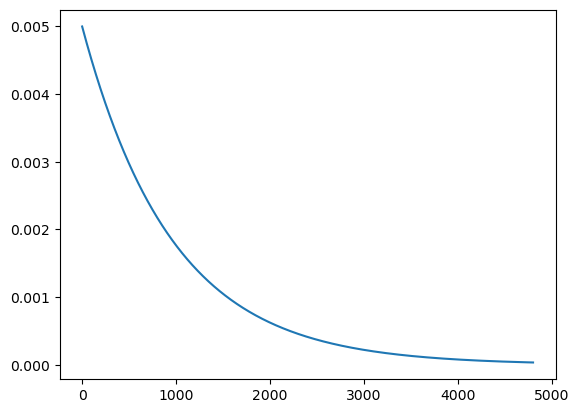

In [3]:
rate = 32e6
pulse_duration = 150e-6
pulse_len = int(pulse_duration * rate)
tp = np.arange(pulse_len) / rate
tau = 30e-6
plt.plot(0.005* np.exp(-tp / tau) * np.exp(1j * 2 * np.pi * tp))

In [3]:
fs = 1e6
T = 1.0

N = int(fs * T)

In [4]:
f_1 = 1e3

phi_1 = np.pi/4

t_1 = np.arange(0, 1, 1/fs)

signal_1 = np.sin(2*np.pi*f_1*t_1 + phi_1)

In [5]:
signal_1

array([0.70710678, 0.71153568, 0.71593648, ..., 0.69365331, 0.69816542,
       0.70264997])

Text(0, 0.5, 'Time s')

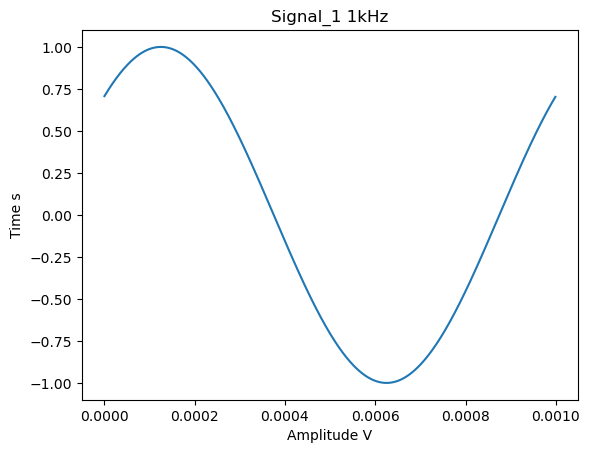

In [6]:
plt.figure()
plt.plot(t_1[0:1000], signal_1[0:1000])
plt.title("Signal_1 1kHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

In [7]:
f_2 = 7e3
phi_2 = np.pi/3
t_2 = np.arange(0, 1, 1/fs)

signal_2 = np.cos(2*np.pi*f_2*t_2 + phi_2)

Text(0, 0.5, 'Time s')

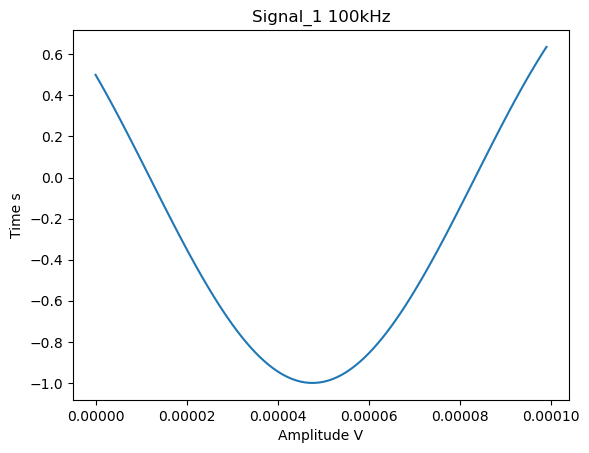

In [8]:
plt.figure()
plt.plot(t_2[0:100], signal_2[0:100])
plt.title("Signal_1 100kHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

In [9]:
signal_1.shape, signal_2.shape

((1000000,), (1000000,))

In [10]:
f_3 = 5e3
phi_3 = np.pi/2
t_3 = np.arange(0, 1, 1/fs)

signal_3 = np.cos(2*np.pi*f_3*t_3 + phi_3)

Text(0, 0.5, 'Time s')

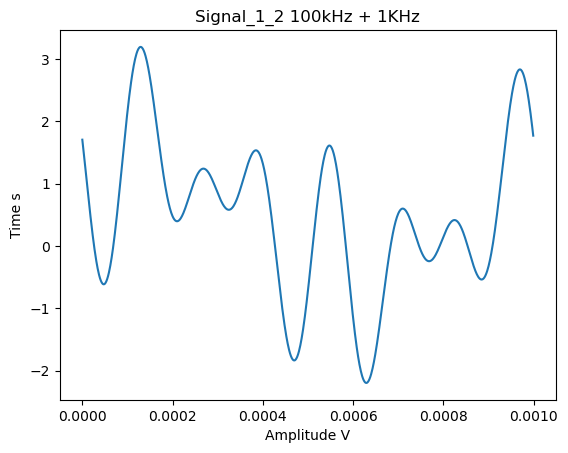

In [22]:
dc_offset = 0.5
signal_1_2_3 = signal_1_2_3 + dc_offset
noise = 1000*np.random.randn(len(signal_1_2_3)) *0

signal_1_2_3 = signal_1_2_3 + noise

plt.figure()
plt.plot(t_1[0:1000], signal_1_2_3[0:1000])
plt.title("Signal_1_2 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

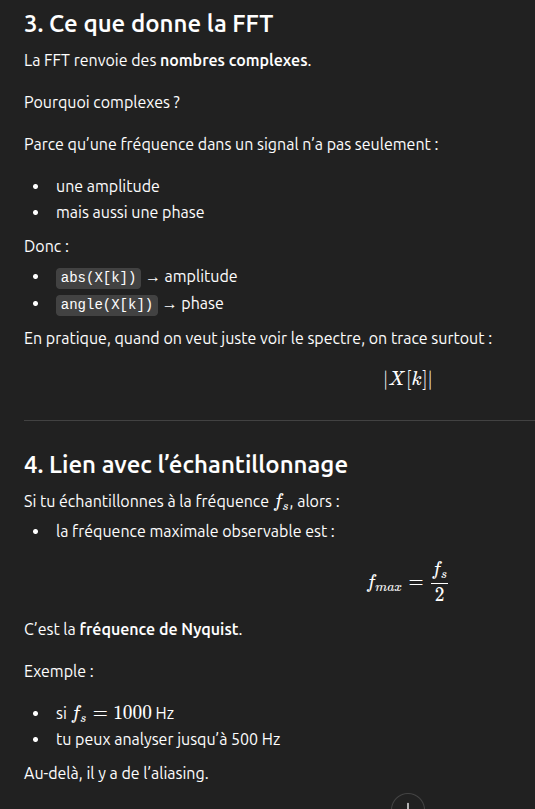
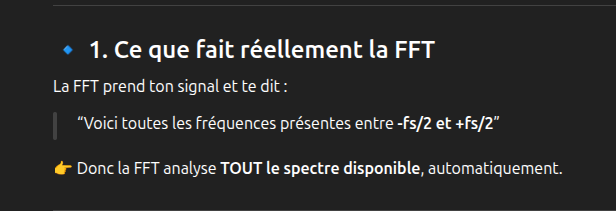
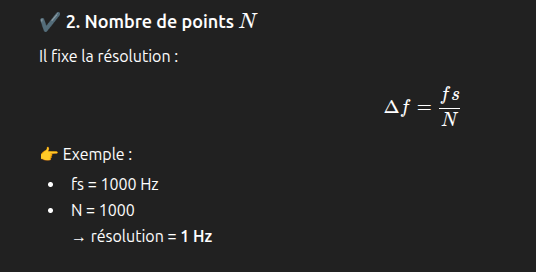

In [23]:
X = np.fft.fft(signal_1_2_3)

freq = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

phase = np.angle(X)

freq.shape, Ampl.shape, phase.shape

((1000000,), (1000000,), (1000000,))

In [24]:
(2e9 - 100e6 - 38e6)/(38e6)

49.0

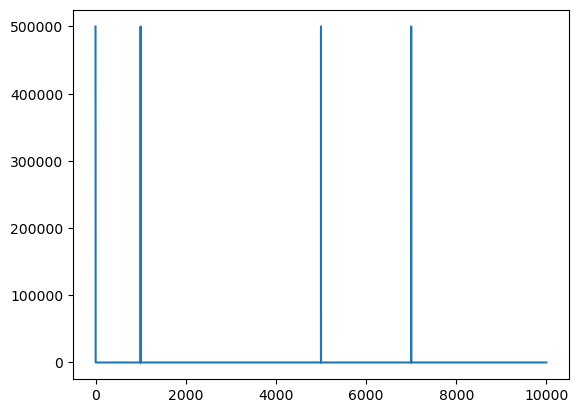

Pic à 1000.000 Hz
Pic à 5000.000 Hz
Pic à 7000.000 Hz
Pic à -7000.000 Hz
Pic à -5000.000 Hz
Pic à -1000.000 Hz


In [25]:
plt.figure()
alpha = int(len(freq)/100)
plt.plot(freq[:alpha], Ampl[:alpha])
# plt.plot(freqs[:], phase[:])

peaks, properties = find_peaks(Ampl, height=10)
# plt.plot(freqs[peaks], Ampl[peaks], "rx") 
plt.show()
for p in peaks:
    print(f"Pic à {freq[p]/1:.3f} Hz")
# plt.xlim(-50000, 50000)
# plt.ylim(0, 200)

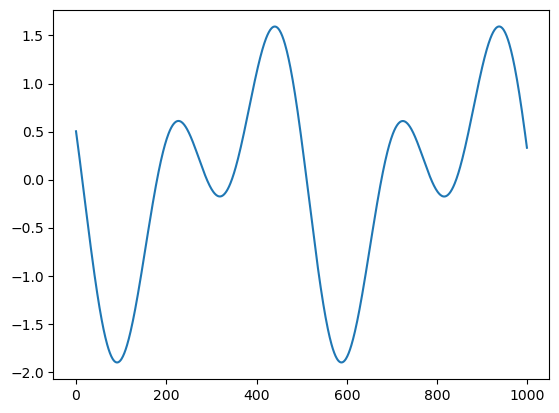

In [41]:
X_filtred = X[np.abs(freq) > 3000]
signal_filtered_freq_domain = np.real(np.fft.ifft(X_filtred))

plt.figure()
plt.plot(signal_filtered_freq_domain[:1000])
plt.show()

In [42]:
X_pf = np.fft.fft(signal_filtered_freq_domain)

freq_pf = np.fft.fftfreq(N, d=1/fs)

Ampl_pf = np.abs(X_pf)


freq_pf.shape, Ampl_pf.shape

((1000000,), (993999,))

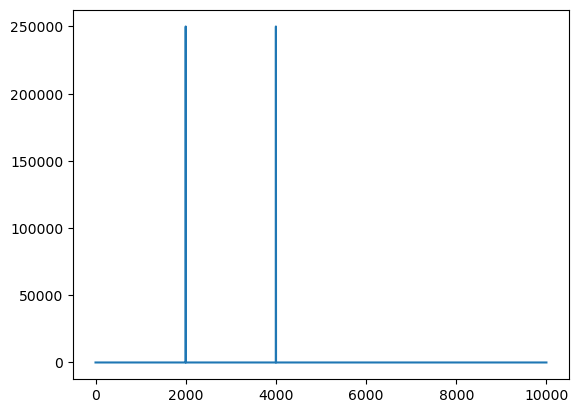

In [46]:
plt.figure()
plt.plot(freq_pf[:10000], Ampl_pf[:10000])
plt.show()

# Hightpass

In [159]:
cutoff = 6000

Wn = cutoff/(fs/2)

# Création du filtre
b, a = butter(N=8, Wn=Wn, btype='highpass')
w, h = signal.freqs(b ,a)
# Application du filtre
signal_filtered = filtfilt(b, a, signal_1_2_3)

In [160]:
b.shape, a.shape, signal_filtered.shape, Wn

((9,), (9,), (1000000,), 0.012)

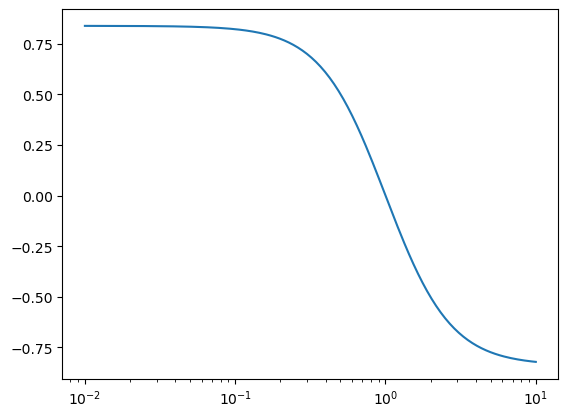

In [161]:
plt.figure()
# plt.plot(w, 20*np.log10(np.abs(h)))
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.show()

In [ ]:
plt.figure()
plt.plot()
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

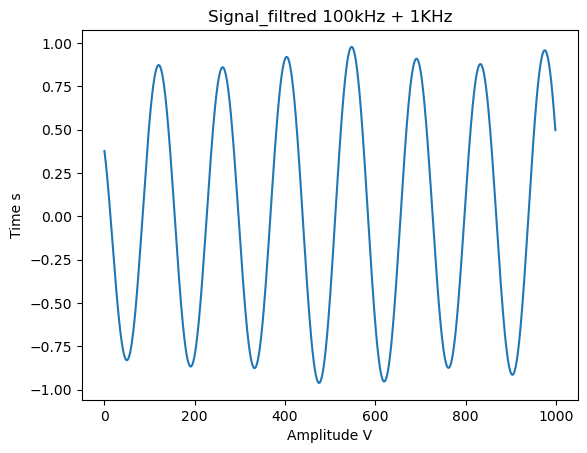

In [150]:
X = np.fft.fft(signal_filtered)

freqs = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

plt.figure()
plt.plot(signal_filtered[0:1000])
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

# bandpass

In [140]:
f_low = 3000
f_high = 6000

Wn = [f_low/(fs/2), f_high/(fs/2)]

# Création du filtre
b, a = butter(N=4, Wn=Wn, btype='bandpass')
w, h = signal.freqs(b ,a)
# Application du filtre
signal_filtered = filtfilt(b, a, signal_1_2_3)

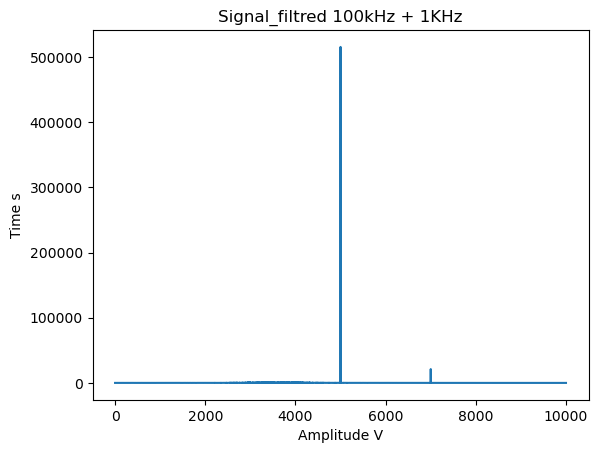

In [141]:
X = np.fft.fft(signal_filtered)

freqs = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

plt.figure()
plt.plot(freqs[0:10000], Ampl[0:10000])
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

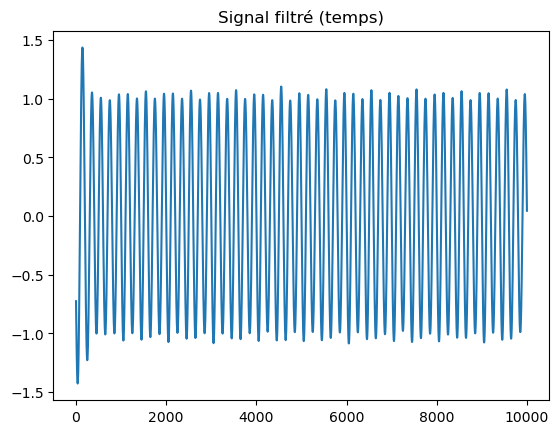

In [144]:
plt.plot(signal_filtered[:10000])
plt.title("Signal filtré (temps)")
plt.show()

# Part 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
fs = 32e6              # fréquence d'échantillonnage (1 MHz)
t = np.arange(0, 0.01, 1/fs)  # 10 ms

f_signal = 105e6      # signal à 100 kHz

# signal complexe (IQ)
samples = np.exp(1j * 2 * np.pi * f_signal * t)

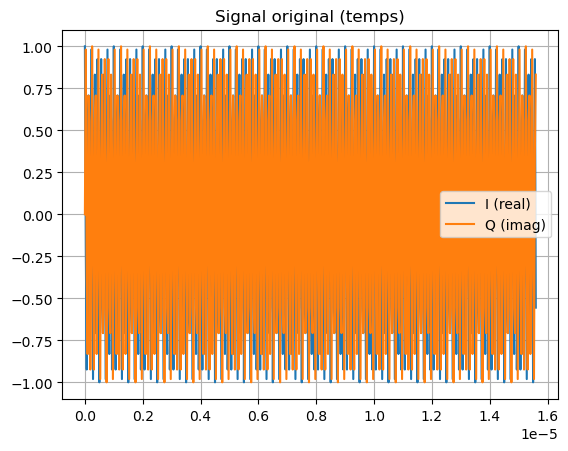

In [25]:
plt.figure()
plt.plot(t[:500], np.real(samples[:500]), label="I (real)")
plt.plot(t[:500], np.imag(samples[:500]), label="Q (imag)")
plt.title("Signal original (temps)")
plt.legend()
plt.grid()
plt.show()

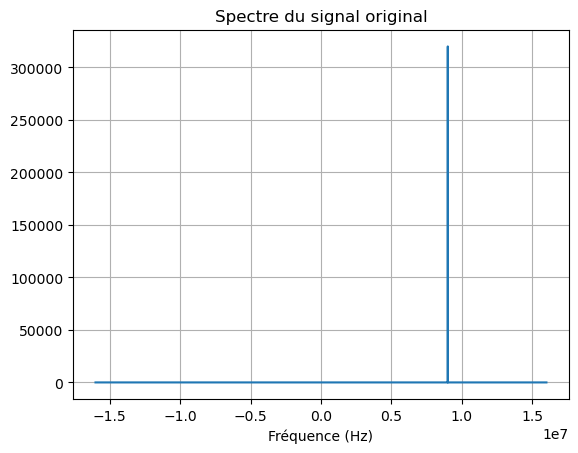

In [26]:
def plot_fft(signal, fs, title):
    N = len(signal)
    freq = np.fft.fftfreq(N, 1/fs)
    spectrum = np.fft.fft(signal)
    
    plt.figure()
    plt.plot(np.fft.fftshift(freq), np.fft.fftshift(np.abs(spectrum)))
    plt.title(title)
    plt.xlabel("Fréquence (Hz)")
    plt.grid()
    plt.show()

plot_fft(samples, fs, "Spectre du signal original")

In [54]:
f_offset = 1e6

samples_dc = samples * np.exp(-1j * 2 * np.pi * f_offset * t)

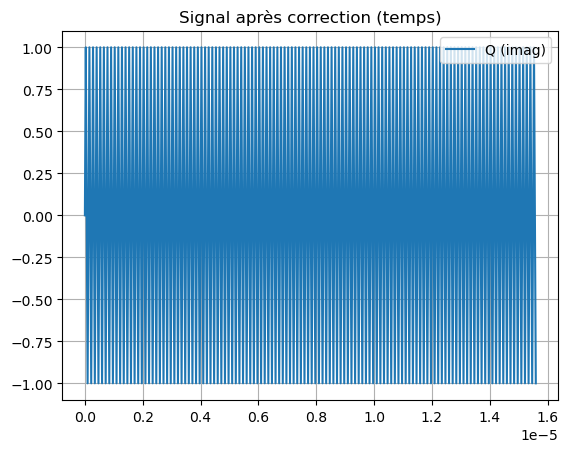

In [55]:
plt.figure()
# plt.plot(t[:], np.real(samples_dc[:]), label="I (real)")
plt.plot(t[:500], np.imag(samples_dc[:500]), label="Q (imag)")
plt.title("Signal après correction (temps)")
plt.legend()
plt.grid()
plt.show()

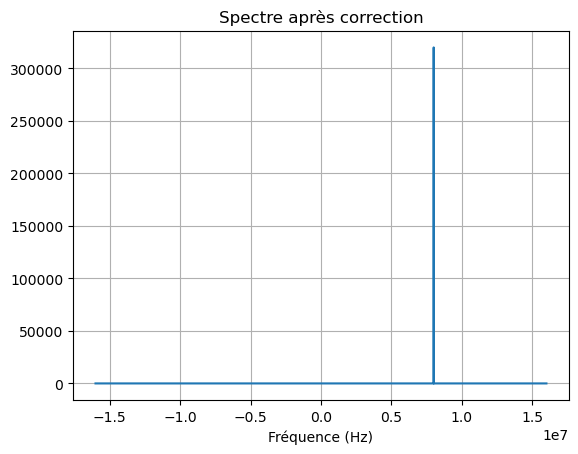

In [56]:
plot_fft(samples_dc, fs, "Spectre après correction")

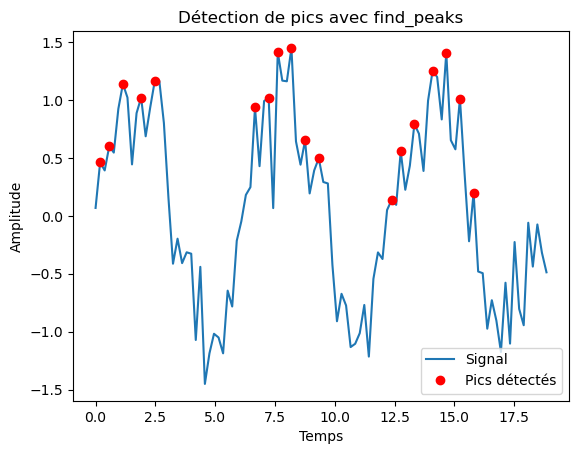

Indices des pics : [ 1  3  6 10 13 35 38 40 43 46 49 65 67 70 74 77 80 83]
Hauteur des pics : [0.46133492 0.60027552 1.13902438 1.02055888 1.16531414 0.93592737
 1.01808668 1.41305371 1.44969905 0.65246904 0.49669219 0.13680504
 0.55739257 0.79244339 1.25306653 1.40841078 1.01276827 0.19957915]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1. Créer un signal (sinus + bruit)
x = np.linspace(0, 6*np.pi, 100)
signal = np.sin(x) + 0.3 * np.random.randn(100)

# 2. Détecter les pics
peaks, properties = find_peaks(signal, height=0)

# 3. Affichage
plt.figure()
plt.plot(x, signal, label="Signal")
plt.plot(x[peaks], signal[peaks], "ro", label="Pics détectés")
plt.legend()
plt.title("Détection de pics avec find_peaks")
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.show()

# 4. Afficher les indices des pics
print("Indices des pics :", peaks)
print("Hauteur des pics :", properties["peak_heights"])

In [2]:
len(peaks)

18

In [4]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print("GPIO banks:", usrp.get_gpio_banks(0))

GPIO banks: ['FP0', 'RXA', 'TXA']


In [2]:
import uhd
import time

usrp = uhd.usrp.MultiUSRP()

bank = "FP0"

# Mettre bits 8 et 9 en entrée
usrp.set_gpio_attr(bank, "DDR", 0x000, 0x300)

# for i in range(0, 5):
while True:
    value = usrp.get_gpio_attr(bank, "READBACK")
    gpio8 = (value >> 8) & 1
    gpio9 = (value >> 9) & 1

    print("GPIO8 =", gpio8, "GPIO9 =", gpio9)
    time.sleep(0.1)

GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1


[INFO] [B200] Loading firmware image: /usr/share/uhd/images/usrp_b200_fw.hex...
[INFO] [B200] Detected Device: B200
[INFO] [B200] Loading FPGA image: /usr/share/uhd/images/usrp_b200_fpga.bin...
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Detecting internal GPSDO.... 
[INFO] [GPS] No GPSDO found
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.


GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1


RuntimeError: AssertionError: accum_timeout < _timeout
  in wait_for_ack
  at ./host/lib/usrp/b200/b200_radio_ctrl_core.cpp:227


[ERROR] [UHD] An unexpected exception was caught in a task loop.The task loop will now exit, things may not work.EnvironmentError: IOError: usb rx8 transfer status: LIBUSB_TRANSFER_NO_DEVICE


In [9]:
import uhd
import time

usrp = uhd.usrp.MultiUSRP()
bank = "FP0"

MASK = 0x300  # GPIO8 + GPIO9

usrp.set_gpio_attr(bank, "DDR", MASK, MASK)

while True:
    usrp.set_gpio_attr(bank, "OUT", MASK, MASK)
    print("OUT HIGH =", hex(usrp.get_gpio_attr(bank, "OUT")))
    time.sleep(5)

    usrp.set_gpio_attr(bank, "OUT", 0x000, MASK)
    print("OUT LOW  =", hex(usrp.get_gpio_attr(bank, "OUT")))
    time.sleep(5)

OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300


KeyboardInterrupt: 

[ERROR] [UHD] An unexpected exception was caught in a task loop.The task loop will now exit, things may not work.EnvironmentError: IOError: usb rx8 transfer status: LIBUSB_TRANSFER_NO_DEVICE


In [10]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print("RX channels:", usrp.get_rx_num_channels())

RX channels: 1


In [3]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print("RX channels:", usrp.get_rx_num_channels())
print("TX channels:", usrp.get_tx_num_channels())

print("RX0 antennas:", usrp.get_rx_antennas(0))
print("RX1 antennas:", usrp.get_rx_antennas(1))

RX channels: 2
TX channels: 2
RX0 antennas: ['TX/RX', 'RX2']
RX1 antennas: ['TX/RX', 'RX2']


[INFO] [B200] Detected Device: B210
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.


In [1]:
import uhd
import numpy as np

FREQ = 100e6
RATE = 1e6
GAIN = 30
NUM_SAMPS = 100000

usrp = uhd.usrp.MultiUSRP()

samples = usrp.recv_num_samps(
    NUM_SAMPS,
    FREQ,
    RATE,
    [0, 1],
    GAIN
)

print(samples.shape)

rx0 = samples[0]
rx1 = samples[1]

[INFO] [UHD] linux; GNU C++ version 13.2.0; Boost_108300; UHD_4.6.0.0+ds1-5.1ubuntu0.24.04.1
[INFO] [B200] Detected Device: B200
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.
[INFO] [B200] Asking for clock rate 32.000000 MHz... 
[INFO] [B200] Actually got clock rate 32.000000 MHz.


RuntimeError: LookupError: IndexError: multi_usrp: RX channel 1 out of range for configured RX frontends

In [5]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print(usrp.get_gpio_banks(0))

['FP0', 'RXA', 'TXA']


In [6]:
import uhd
import time

usrp = uhd.usrp.MultiUSRP()

bank = "FP0"

MASK = 0x300   # GPIO8 + GPIO9
GPIO8 = 0x100
GPIO9 = 0x200

# config en sortie
usrp.set_gpio_attr(bank, "DDR", MASK, MASK)

while True:
    # GPIO8 HIGH
    usrp.set_gpio_attr(bank, "OUT", GPIO8, MASK)
    print("GPIO8 ON")
    time.sleep(3)

    # GPIO9 HIGH
    usrp.set_gpio_attr(bank, "OUT", GPIO9, MASK)
    print("GPIO9 ON")
    time.sleep(3)

    # OFF
    usrp.set_gpio_attr(bank, "OUT", 0x000, MASK)
    print("ALL OFF")
    time.sleep(3)

GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON


KeyboardInterrupt: 

In [33]:
a = 0.0015
db = 20 * np.log10(a)
dbm = 10 * np.log10((a*a)/((1e-3)*50))
print(f"{a} V = {db} db = {dbm} dbm")

0.0015 V = -56.47817481888637 db = -43.46787486224656 dbm


In [34]:
a = 0.041
db = 20 * np.log10(a)
dbm = 10 * np.log10((a*a)/((1e-3)*50))
print(f"{a} V = {db} db = {dbm} dbm")

0.041 V = -27.74432286560529 db = -14.734022908965478 dbm


In [32]:
a = 0.01
db = 20 * np.log10(a)
dbm = 10 * np.log10((a*a)/((1e-3)*50))
print(f"{a} V = {db} db = {dbm} dbm")

0.01 V = -40.0 db = -26.989700043360187 dbm


In [2]:
dbm = -15   # exemple

v = np.sqrt(50 * 1e-3 * 10**(dbm / 10))

print(f"{dbm} dBm = {v} V RMS")

-15 dBm = 0.03976353643835254 V RMS


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import uhd
from scipy.signal import butter, filtfilt, freqs, find_peaks
import os


# =======================
# CONFIGURATION
# =======================
FREQ = 100e6
GAIN = 80
CHANNEL0 = 0
CHANNEL1 = 1
RATE = 10e6
NFFT = 4096
DURATION = 0.5


usrp = uhd.usrp.MultiUSRP()

num_samps = int(DURATION * RATE)

samples_2dim = usrp.recv_num_samps(
    num_samps,
    FREQ,
    RATE,
    [CHANNEL0],
    GAIN
)

print("Sample ndim ========= ", samples_2dim.ndim)
if samples_2dim.ndim == 2:
    samples = samples_2dim[0]
    # samples_p = samples_2dim[1]

print(f"Received {len(samples)} samples")
print(type(samples))

Sample ndim =========  2
Received 5000000 samples
<class 'numpy.ndarray'>


In [29]:
def compute_spectrum_dbm_per_bin(samples, rate, freq_center, nfft=4096, R=50, remove_dc=True):
    samples = np.asarray(samples, dtype=np.complex64).ravel()

    if len(samples) < nfft:
        return np.array([]), np.array([])

    if remove_dc:
        samples = samples - np.mean(samples)

    n_blocks = len(samples) // nfft
    samples = samples[:n_blocks * nfft]
    blocks = samples.reshape(n_blocks, nfft)

    window = np.hanning(nfft)
    coherent_gain = np.sum(window) / nfft

    p_acc = np.zeros(nfft)

    for blk in blocks:
        xw = blk * window
        X = np.fft.fftshift(np.fft.fft(xw, n=nfft))

        vrms_bin = np.abs(X) / (nfft * coherent_gain * np.sqrt(2))
        p_w_bin = (vrms_bin ** 2) / R

        p_acc += p_w_bin

    p_mean = p_acc / n_blocks

    p_dbm_bin = 10 * np.log10(np.clip(p_mean / 1e-3, 1e-20, None))

    freqs = np.fft.fftshift(np.fft.fftfreq(nfft, d=1 / rate)) + freq_center

    return freqs, p_dbm_bin

def plot_spectrum(freqs, psd_dbm, name="Freq_domain_plot"):
    if len(freqs) == 0:
        print("Spectre vide.")
        return

    plt.figure(figsize=(12, 5))
    plt.plot(freqs / 1e6, psd_dbm, color="green")

    plt.title("Spectre FFT - Puissance approximative en dBm/bin")
    plt.xlabel("Fréquence (MHz)")
    plt.ylabel("Puissance approximative (dBm/bin)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

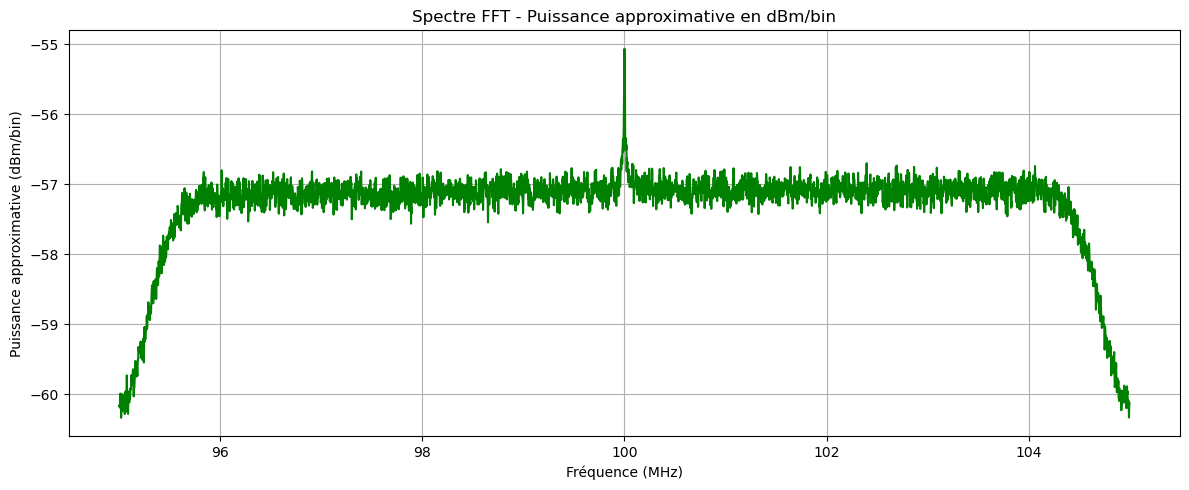

In [30]:
freqs, p_dbm = compute_spectrum_dbm_per_bin(samples, RATE, FREQ)
alpha = len(freqs)-500
alpha = 0
plot_spectrum(freqs[alpha:], p_dbm[alpha:])